In [2]:
import pandas as pd

budget=pd.read_csv("Budget.csv")
transactions=pd.read_csv("personal_transactions.csv")

print("Budget shape: ",budget.shape)
print("Transactions shape: ",transactions.shape)

Budget shape:  (19, 2)
Transactions shape:  (806, 6)


In [3]:
print("----Budget----")
print(budget.head())

print("\n----Transactions----")
print(transactions.head())

----Budget----
                 Category  Budget
0          Alcohol & Bars      50
1          Auto Insurance      75
2            Coffee Shops      15
3  Electronics & Software       0
4           Entertainment      25

----Transactions----
         Date          Description   Amount Transaction Type  \
0  01/01/2018               Amazon    11.11            debit   
1  01/02/2018     Mortgage Payment  1247.44            debit   
2  01/02/2018      Thai Restaurant    24.22            debit   
3  01/03/2018  Credit Card Payment  2298.09           credit   
4  01/04/2018              Netflix    11.76            debit   

              Category   Account Name  
0             Shopping  Platinum Card  
1      Mortgage & Rent       Checking  
2          Restaurants    Silver Card  
3  Credit Card Payment  Platinum Card  
4        Movies & DVDs  Platinum Card  


In [4]:
print("=== BUDGET COLUMNS ===")
print(budget.dtypes)

print("\n=== TRANSACTIONS COLUMNS ===")
print(transactions.dtypes)

=== BUDGET COLUMNS ===
Category      str
Budget      int64
dtype: object

=== TRANSACTIONS COLUMNS ===
Date                    str
Description             str
Amount              float64
Transaction Type        str
Category                str
Account Name            str
dtype: object


In [5]:
print("=== MISSING VALUES ===")
print("Budget:\n", budget.isnull().sum())
print("\nTransactions:\n", transactions.isnull().sum())

transactions['Date'] = pd.to_datetime(transactions['Date'])
print("\nEarliest date:", transactions['Date'].min())
print("Latest date:", transactions['Date'].max())

print("\nTransaction Categories:\n", transactions['Category'].unique())

=== MISSING VALUES ===
Budget:
 Category    0
Budget      0
dtype: int64

Transactions:
 Date                0
Description         0
Amount              0
Transaction Type    0
Category            0
Account Name        0
dtype: int64

Earliest date: 2018-01-01 00:00:00
Latest date: 2019-09-30 00:00:00

Transaction Categories:
 <ArrowStringArray>
[              'Shopping',        'Mortgage & Rent',            'Restaurants',
    'Credit Card Payment',          'Movies & DVDs',       'Home Improvement',
              'Utilities',                  'Music',           'Mobile Phone',
             'Gas & Fuel',              'Groceries',               'Paycheck',
              'Fast Food',           'Coffee Shops',               'Internet',
                'Haircut',         'Alcohol & Bars',         'Auto Insurance',
          'Entertainment',          'Food & Dining',             'Television',
 'Electronics & Software']
Length: 22, dtype: str


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

spending = transactions[transactions['Transaction Type']=='debit']

actual_spending = spending.groupby('Category')['Amount'].sum().reset_index()
actual_spending.columns = ['Category', 'Total Spent']

comparison = pd.merge(budget, actual_spending, on='Category', how='left')
comparison['Budget'] = comparison['Budget'].fillna(0)
comparison=comparison.sort_values('Total Spent', ascending=False)

print(comparison)

                  Category  Budget  Total Spent
12         Mortgage & Rent    1100     24754.50
9         Home Improvement     250     19092.87
7                Groceries     150      2795.21
18               Utilities     150      2776.00
15             Restaurants     150      2613.02
16                Shopping     100      1973.24
6               Gas & Fuel      75      1715.17
11            Mobile Phone      65      1680.40
10                Internet      75      1570.88
1           Auto Insurance      75      1350.00
3   Electronics & Software       0       719.00
0           Alcohol & Bars      50       539.13
8                  Haircut      30       378.00
5                Fast Food      15       330.63
14                   Music      11       224.49
13           Movies & DVDs       0       222.19
2             Coffee Shops      15       115.54
17              Television      15       104.78
4            Entertainment      25         9.62


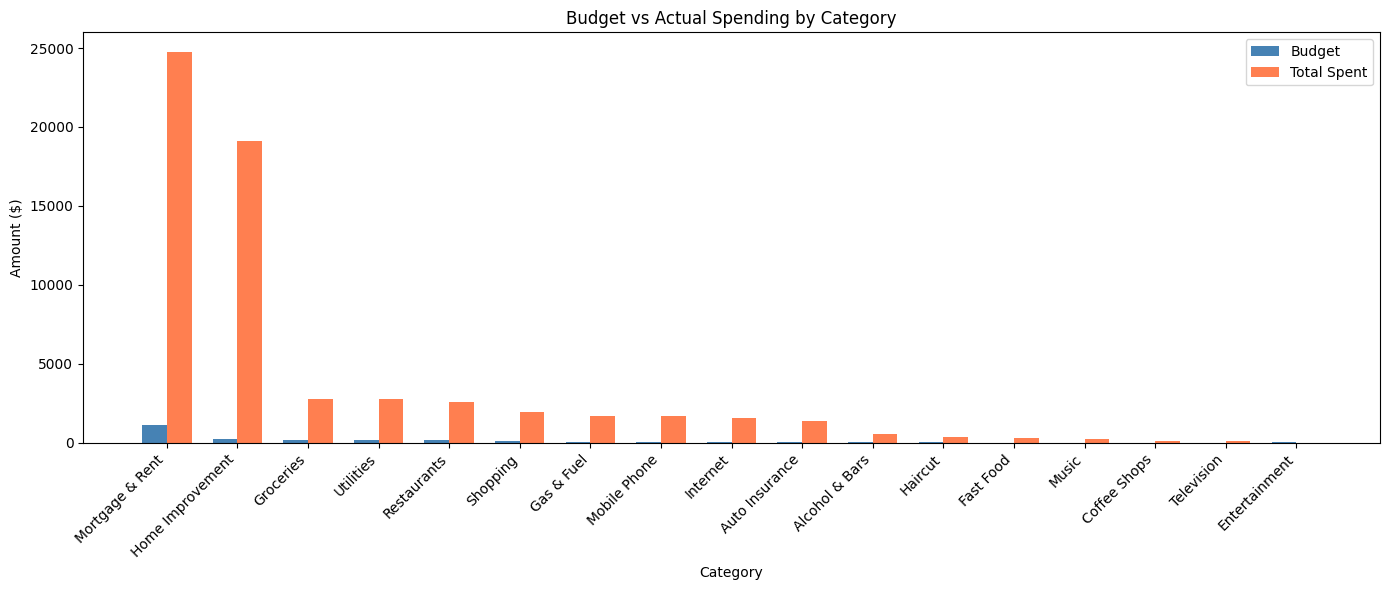

Chart saved!


In [7]:
import matplotlib.pyplot as plt
import numpy as np

comparison_filtered = comparison[comparison['Budget'] > 0].copy()

comparison_filtered['Overspend'] = comparison_filtered['Total Spent'] - comparison_filtered['Budget']

x = range(len(comparison_filtered))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar([i - width/2 for i in x], comparison_filtered['Budget'], 
               width, label='Budget', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], comparison_filtered['Total Spent'], 
               width, label='Total Spent', color='coral')

ax.set_xlabel('Category')
ax.set_ylabel('Amount ($)')
ax.set_title('Budget vs Actual Spending by Category')
ax.set_xticks(list(x))
ax.set_xticklabels(comparison_filtered['Category'], rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig('budget_vs_actual.png')
plt.show()

print("Chart saved!")

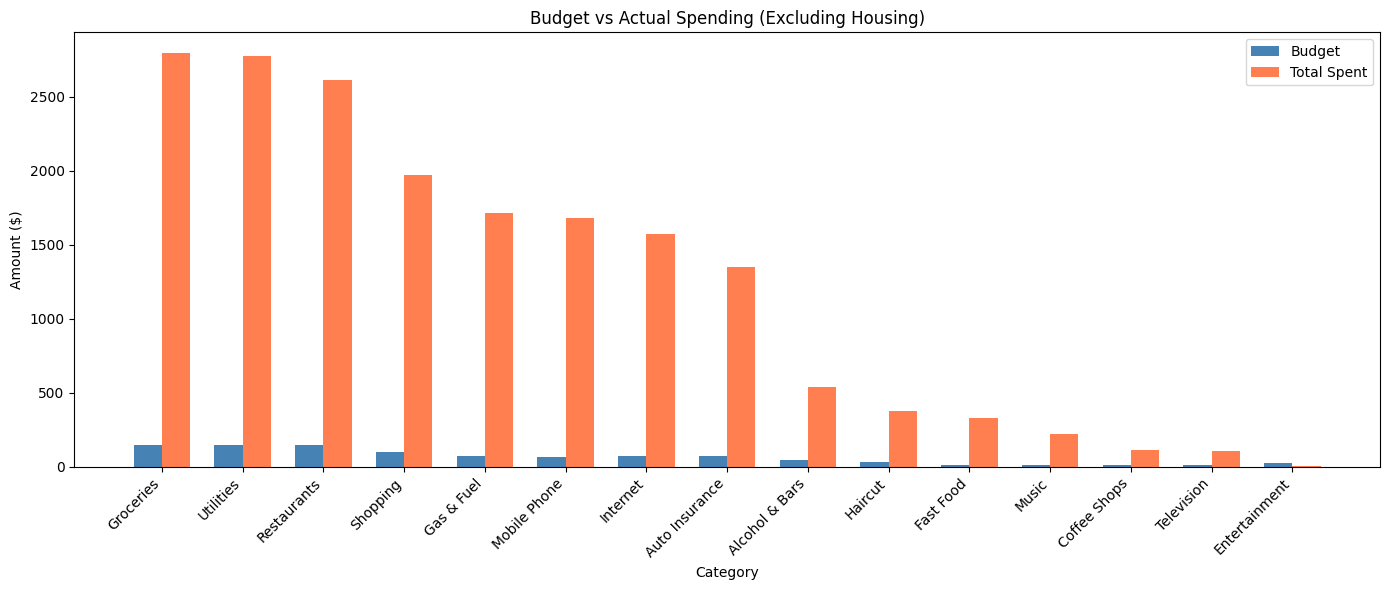

In [8]:
# Remove Mortgage & Home Improvement to see smaller categories clearly
comparison_small = comparison_filtered[
    ~comparison_filtered['Category'].isin(['Mortgage & Rent', 'Home Improvement'])
].copy()

x = range(len(comparison_small))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar([i - width/2 for i in x], comparison_small['Budget'], 
       width, label='Budget', color='steelblue')
ax.bar([i + width/2 for i in x], comparison_small['Total Spent'], 
       width, label='Total Spent', color='coral')

ax.set_xlabel('Category')
ax.set_ylabel('Amount ($)')
ax.set_title('Budget vs Actual Spending (Excluding Housing)')
ax.set_xticks(list(x))
ax.set_xticklabels(comparison_small['Category'], rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig('budget_vs_actual_small.png')
plt.show()

In [9]:
# Save our cleaned comparison table as a CSV
comparison.to_csv('spending_analysis.csv', index=False)
print("Data saved!")

# Quick summary of key insights
print("\n=== KEY INSIGHTS ===")
print(f"Total categories tracked: {len(comparison)}")
print(f"Total spent overall: ${spending['Amount'].sum():,.2f}")
print(f"Date range: {transactions['Date'].min().date()} to {transactions['Date'].max().date()}")
print(f"Total transactions: {len(transactions)}")

overspent = comparison_filtered[comparison_filtered['Total Spent'] > comparison_filtered['Budget']]
print(f"Categories over budget: {len(overspent)} out of {len(comparison_filtered)}")

Data saved!

=== KEY INSIGHTS ===
Total categories tracked: 19
Total spent overall: $96,083.78
Date range: 2018-01-01 to 2019-09-30
Total transactions: 806
Categories over budget: 16 out of 17


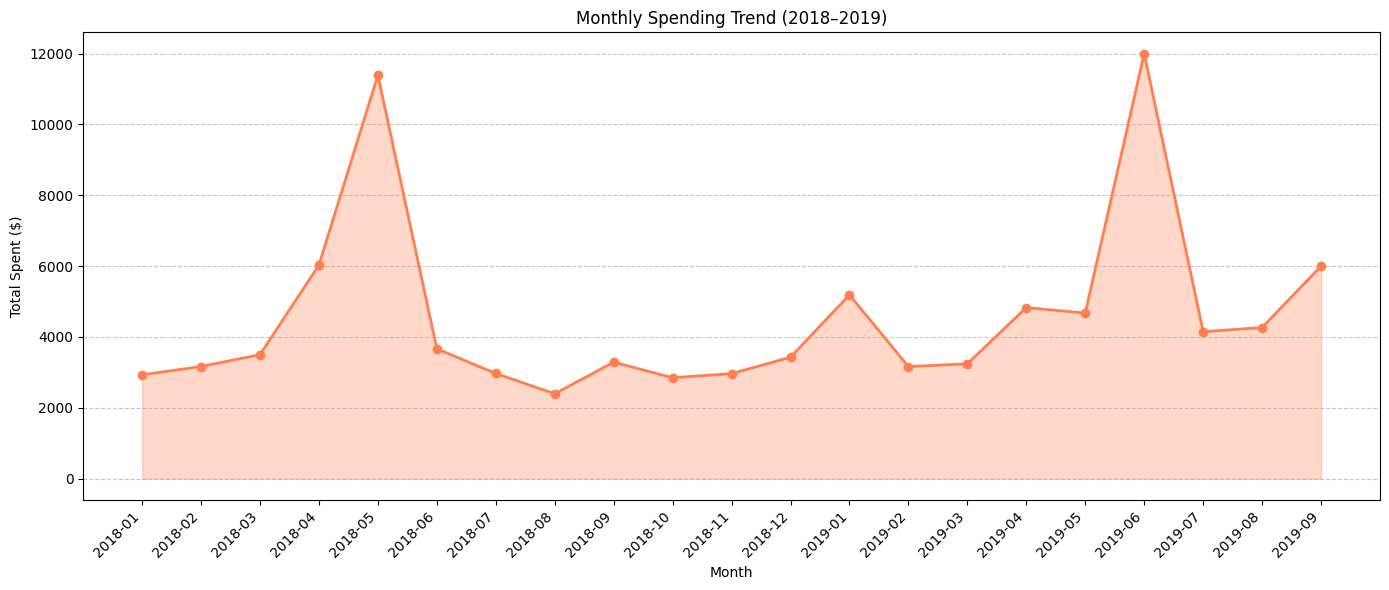

Highest spending month: 2019-06 — $11,999.60
Lowest spending month: 2018-08 — $2,396.18


In [10]:
# Extract month and year from date
spending['Month'] = spending['Date'].dt.to_period('M')

# Total spending per month
monthly_spending = spending.groupby('Month')['Amount'].sum().reset_index()
monthly_spending['Month'] = monthly_spending['Month'].astype(str)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_spending['Month'], monthly_spending['Amount'], 
        marker='o', color='coral', linewidth=2, markersize=6)
ax.fill_between(range(len(monthly_spending)), monthly_spending['Amount'], 
                alpha=0.3, color='coral')
ax.set_xticks(range(len(monthly_spending)))
ax.set_xticklabels(monthly_spending['Month'], rotation=45, ha='right')
ax.set_xlabel('Month')
ax.set_ylabel('Total Spent ($)')
ax.set_title('Monthly Spending Trend (2018–2019)')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.show()

print(f"Highest spending month: {monthly_spending.loc[monthly_spending['Amount'].idxmax(), 'Month']} — ${monthly_spending['Amount'].max():,.2f}")
print(f"Lowest spending month: {monthly_spending.loc[monthly_spending['Amount'].idxmin(), 'Month']} — ${monthly_spending['Amount'].min():,.2f}")

Top 5 categories: ['Credit Card Payment', 'Groceries', 'Utilities', 'Restaurants', 'Shopping']


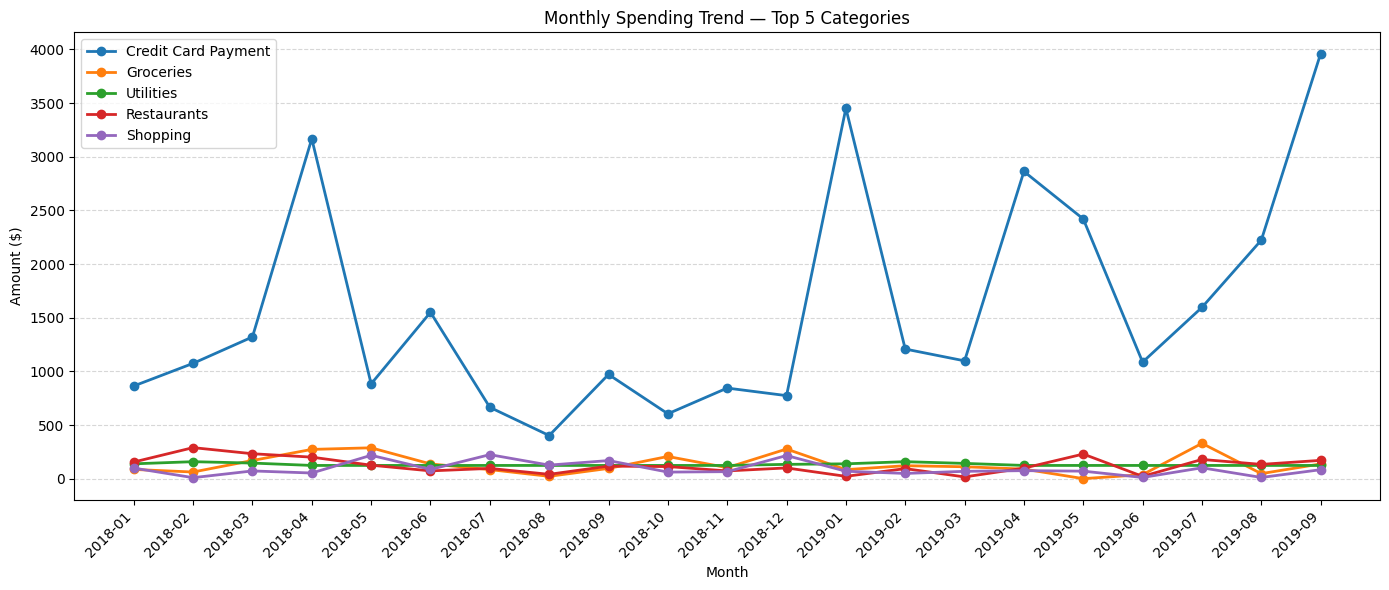

In [11]:
# Top 5 categories by total spending (excluding housing)
top_categories = spending[
    ~spending['Category'].isin(['Mortgage & Rent', 'Home Improvement'])
].groupby('Category')['Amount'].sum().nlargest(5).index.tolist()

print("Top 5 categories:", top_categories)

# Monthly trend for each top category
category_monthly = spending[spending['Category'].isin(top_categories)]\
    .groupby(['Month', 'Category'])['Amount'].sum().reset_index()
category_monthly['Month'] = category_monthly['Month'].astype(str)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

for category in top_categories:
    data = category_monthly[category_monthly['Category'] == category]
    ax.plot(data['Month'], data['Amount'], marker='o', label=category, linewidth=2)

ax.set_xlabel('Month')
ax.set_ylabel('Amount ($)')
ax.set_title('Monthly Spending Trend — Top 5 Categories')
ax.legend()
ax.set_xticks(range(len(category_monthly['Month'].unique())))
ax.set_xticklabels(category_monthly['Month'].unique(), rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('category_trends.png')
plt.show()

Top 5 real spending categories: ['Groceries', 'Utilities', 'Restaurants', 'Shopping', 'Gas & Fuel']


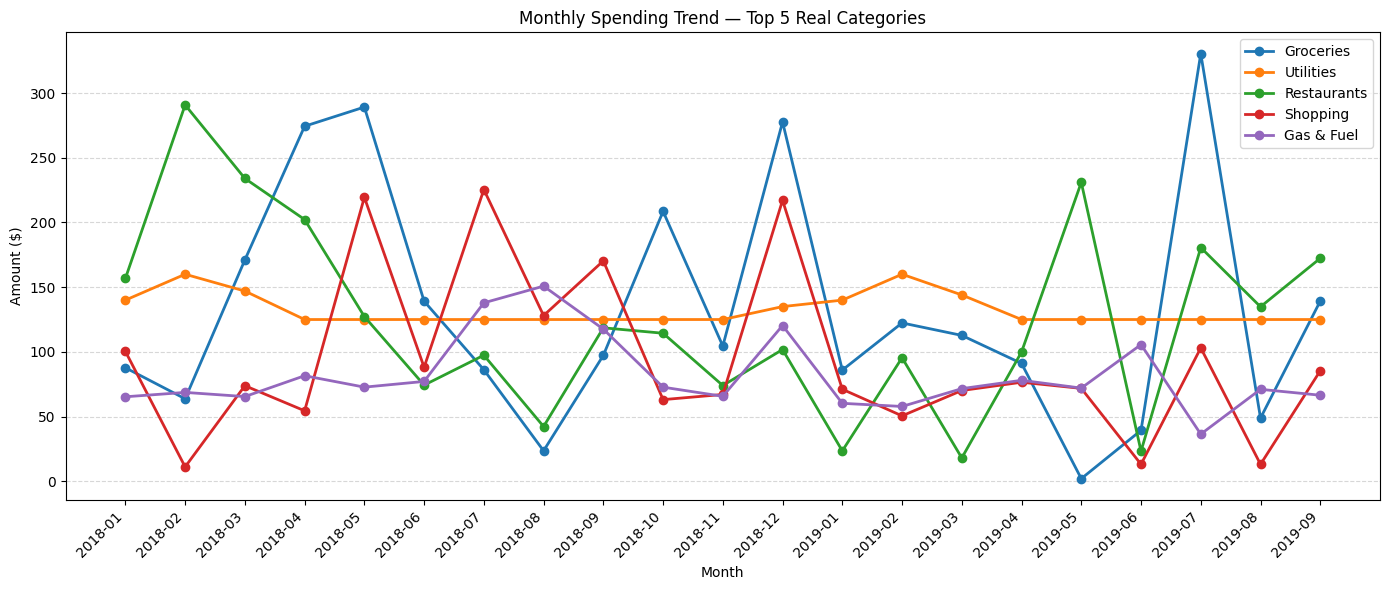

In [12]:
# Remove Credit Card Payment as it's not a true spending category
top_categories_clean = spending[
    ~spending['Category'].isin(['Mortgage & Rent', 'Home Improvement', 'Credit Card Payment'])
].groupby('Category')['Amount'].sum().nlargest(5).index.tolist()

print("Top 5 real spending categories:", top_categories_clean)

# Monthly trend for clean top 5
category_monthly_clean = spending[spending['Category'].isin(top_categories_clean)]\
    .groupby(['Month', 'Category'])['Amount'].sum().reset_index()
category_monthly_clean['Month'] = category_monthly_clean['Month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))

for category in top_categories_clean:
    data = category_monthly_clean[category_monthly_clean['Category'] == category]
    ax.plot(data['Month'], data['Amount'], marker='o', label=category, linewidth=2)

ax.set_xlabel('Month')
ax.set_ylabel('Amount ($)')
ax.set_title('Monthly Spending Trend — Top 5 Real Categories')
ax.legend()
ax.set_xticks(range(len(category_monthly_clean['Month'].unique())))
ax.set_xticklabels(category_monthly_clean['Month'].unique(), rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('category_trends_clean.png')
plt.show()

In [13]:
# Build monthly feature table for clustering
monthly_features = spending.groupby('Month').agg(
    total_spent=('Amount', 'sum'),
    transaction_count=('Amount', 'count'),
    avg_transaction=('Amount', 'mean'),
    max_transaction=('Amount', 'max'),
    unique_categories=('Category', 'nunique')
).reset_index()

monthly_features['Month'] = monthly_features['Month'].astype(str)

print(monthly_features)

      Month  total_spent  transaction_count  avg_transaction  max_transaction  \
0   2018-01      2931.45                 27       108.572222          1247.44   
1   2018-02      3165.05                 27       117.224074          1247.44   
2   2018-03      3500.16                 38        92.109474          1247.44   
3   2018-04      6029.54                 42       143.560476          1247.44   
4   2018-05     11392.03                 35       325.486571          8000.00   
5   2018-06      3665.88                 36       101.830000          1247.44   
6   2018-07      2968.98                 33        89.969091          1247.44   
7   2018-08      2396.18                 25        95.847200          1247.44   
8   2018-09      3286.99                 33        99.605758          1247.44   
9   2018-10      2848.35                 33        86.313636          1209.18   
10  2018-11      2963.65                 37        80.098649          1209.18   
11  2018-12      3427.99    

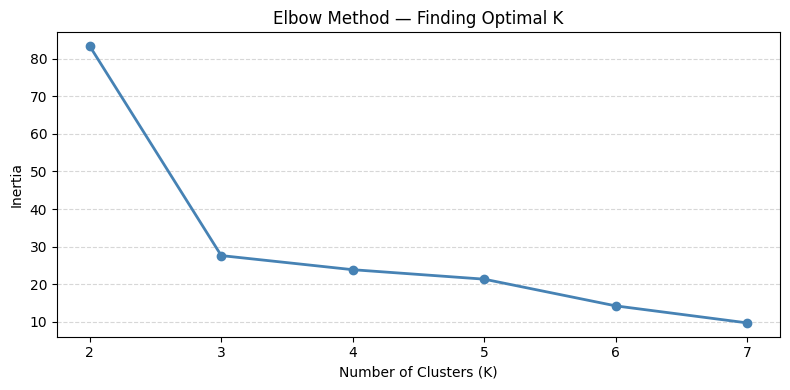

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Select features for clustering
features = ['total_spent', 'transaction_count', 'avg_transaction', 
            'max_transaction', 'unique_categories']

X = monthly_features[features]

# Normalize the data (very important for K-Means!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find the best number of clusters using Elbow Method
inertia = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Optimal K')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('elbow_curve.png')
plt.show()


In [15]:
# Run K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
monthly_features['Cluster'] = kmeans.fit_predict(X_scaled)

# See which months got which cluster
print(monthly_features[['Month', 'total_spent', 'transaction_count', 'Cluster']])

# Count months per cluster
print("\nMonths per cluster:")
print(monthly_features['Cluster'].value_counts())

      Month  total_spent  transaction_count  Cluster
0   2018-01      2931.45                 27        0
1   2018-02      3165.05                 27        0
2   2018-03      3500.16                 38        1
3   2018-04      6029.54                 42        1
4   2018-05     11392.03                 35        2
5   2018-06      3665.88                 36        1
6   2018-07      2968.98                 33        1
7   2018-08      2396.18                 25        0
8   2018-09      3286.99                 33        1
9   2018-10      2848.35                 33        1
10  2018-11      2963.65                 37        1
11  2018-12      3427.99                 46        1
12  2019-01      5187.31                 24        0
13  2019-02      3163.40                 31        1
14  2019-03      3241.51                 28        0
15  2019-04      4829.55                 32        1
16  2019-05      4673.51                 30        0
17  2019-06     11999.60                 27   

=== PERSONA SUMMARY ===
                    months  avg_monthly_spend  avg_transactions  \
Persona                                                           
Cautious Spender 😴       6            3599.17             26.83   
High Spender 🚨           2           11695.81             31.00   
Steady Spender 📊        13            3930.55             35.77   

                    avg_max_transaction  
Persona                                  
Cautious Spender 😴              1307.05  
High Spender 🚨                  8600.00  
Steady Spender 📊                1267.14  


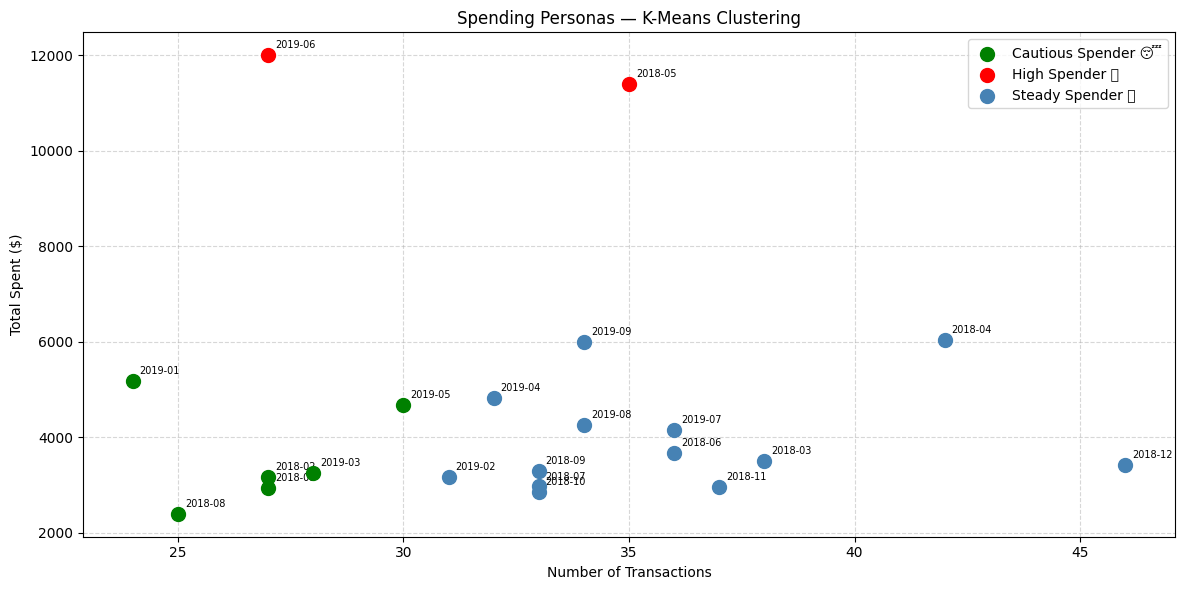

In [16]:
# Name the personas
persona_map = {
    2: 'High Spender 🚨',
    1: 'Steady Spender 📊',
    0: 'Cautious Spender 😴'
}

monthly_features['Persona'] = monthly_features['Cluster'].map(persona_map)

# Print persona summary
print("=== PERSONA SUMMARY ===")
persona_summary = monthly_features.groupby('Persona').agg(
    months=('Month', 'count'),
    avg_monthly_spend=('total_spent', 'mean'),
    avg_transactions=('transaction_count', 'mean'),
    avg_max_transaction=('max_transaction', 'mean')
).round(2)
print(persona_summary)

# Visualize clusters
colors = {'High Spender 🚨': 'red', 
          'Steady Spender 📊': 'steelblue', 
          'Cautious Spender 😴': 'green'}

fig, ax = plt.subplots(figsize=(12, 6))

for persona, group in monthly_features.groupby('Persona'):
    ax.scatter(group['transaction_count'], group['total_spent'],
               label=persona, color=colors[persona], s=100, zorder=5)
    for _, row in group.iterrows():
        ax.annotate(row['Month'], (row['transaction_count'], row['total_spent']),
                   textcoords="offset points", xytext=(5, 5), fontsize=7)

ax.set_xlabel('Number of Transactions')
ax.set_ylabel('Total Spent ($)')
ax.set_title('Spending Personas — K-Means Clustering')
ax.legend()
ax.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('persona_clusters.png')
plt.show()

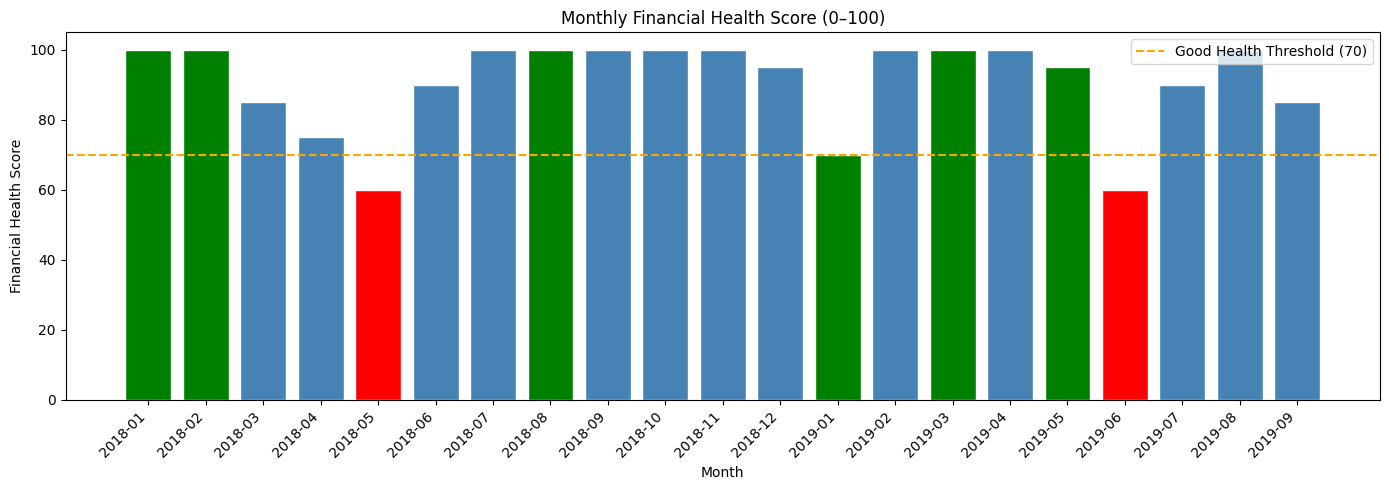


=== HEALTH SCORE SUMMARY ===
  Month            Persona  Health Score
2018-01 Cautious Spender 😴           100
2018-02 Cautious Spender 😴           100
2018-03   Steady Spender 📊            85
2018-04   Steady Spender 📊            75
2018-05     High Spender 🚨            60
2018-06   Steady Spender 📊            90
2018-07   Steady Spender 📊           100
2018-08 Cautious Spender 😴           100
2018-09   Steady Spender 📊           100
2018-10   Steady Spender 📊           100
2018-11   Steady Spender 📊           100
2018-12   Steady Spender 📊            95
2019-01 Cautious Spender 😴            70
2019-02   Steady Spender 📊           100
2019-03 Cautious Spender 😴           100
2019-04   Steady Spender 📊           100
2019-05 Cautious Spender 😴            95
2019-06     High Spender 🚨            60
2019-07   Steady Spender 📊            90
2019-08   Steady Spender 📊           100
2019-09   Steady Spender 📊            85


In [17]:
# Build Financial Health Score for each month
def health_score(row):
    score = 100
    
    # Penalize high spending
    if row['total_spent'] > 5000:
        score -= 30
    elif row['total_spent'] > 3500:
        score -= 15
        
    # Penalize very high single transactions
    if row['max_transaction'] > 5000:
        score -= 25
    elif row['max_transaction'] > 2000:
        score -= 10
        
    # Reward consistent transaction behavior
    if 25 <= row['transaction_count'] <= 35:
        score += 10
        
    # Penalize too many or too few transactions
    if row['transaction_count'] > 45:
        score -= 10
    if row['transaction_count'] < 20:
        score -= 10
        
    # Reward category diversity (well-rounded spending)
    if row['unique_categories'] >= 15:
        score += 5
        
    return max(0, min(100, score))  # Keep score between 0-100

monthly_features['Health Score'] = monthly_features.apply(health_score, axis=1)

# Plot health score over time
fig, ax = plt.subplots(figsize=(14, 5))

colors_score = monthly_features['Persona'].map({
    'High Spender 🚨': 'red',
    'Steady Spender 📊': 'steelblue',
    'Cautious Spender 😴': 'green'
})

ax.bar(monthly_features['Month'], monthly_features['Health Score'], 
       color=colors_score, edgecolor='white')
ax.axhline(y=70, color='orange', linestyle='--', linewidth=1.5, label='Good Health Threshold (70)')
ax.set_xlabel('Month')
ax.set_ylabel('Financial Health Score')
ax.set_title('Monthly Financial Health Score (0–100)')
ax.set_xticklabels(monthly_features['Month'], rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig('health_scores.png')
plt.show()

print("\n=== HEALTH SCORE SUMMARY ===")
print(monthly_features[['Month', 'Persona', 'Health Score']].to_string(index=False))